# 02 - Compare experiments
Reads `outputs/experiments.csv` (one row per training run) and makes the comparison tables and charts for the report: backbone comparison, preprocessing ablation, balancing comparison and hyperparameter tuning.

In [2]:
# Run from the notebooks/ folder: move to the project root so imports and paths work
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
config.ensure_dirs()
config.set_seed()

In [3]:
log = pd.read_csv(config.EXPERIMENT_LOG)
log = log[log["exp_name"] != "quick_test"].drop_duplicates("exp_name", keep="last")
cols = ["exp_name", "backbone", "preprocess", "balance", "dropout", "lr_finetune", "unfreeze",
        "epochs_run", "train_minutes", "params", "val_qwk", "test_accuracy", "test_macro_f1",
        "test_qwk", "test_dr_sensitivity", "test_dr_specificity", "test_dr_auc"]
log[cols].sort_values("test_qwk", ascending=False).round(3)

,exp_name,backbone,preprocess,balance,dropout,lr_finetune,unfreeze,epochs_run,train_minutes,params,val_qwk,test_accuracy,test_macro_f1,test_qwk,test_dr_sensitivity,test_dr_specificity,test_dr_auc
6,effb0_clahe_weights,efficientnetb0,clahe,weights,0.3,0.0,40,36,8.7,4379049,0.873,0.765,0.621,0.851,0.963,0.971,0.992
3,resnet50_full_weights,resnet50,full,weights,0.3,0.0,40,24,6.5,24113798,0.815,0.687,0.528,0.823,0.959,0.988,0.996
2,effb0_full_weights,efficientnetb0,full,weights,0.3,0.0,40,40,9.3,4379049,0.815,0.685,0.545,0.821,0.963,0.942,0.993
5,effb0_raw_weights,efficientnetb0,raw,weights,0.3,0.0,40,30,7.5,4379049,0.840,0.730,0.612,0.818,0.963,0.942,0.988
8,effb0_full_focal,efficientnetb0,full,focal,0.3,0.0,40,40,9.4,4379049,0.820,0.685,0.549,0.816,0.959,0.934,0.992
7,effb0_full_oversample,efficientnetb0,full,oversample,0.3,0.0,40,24,12.5,4379049,0.835,0.704,0.557,0.815,0.976,0.938,0.992
4,mobilenetv2_full_weights,mobilenetv2,full,weights,0.3,0.0,40,35,7.8,2587462,0.804,0.671,0.520,0.778,0.955,0.942,0.990


## Chart helper

In [4]:
def compare(rows, label_col, title, fname, metrics=("test_accuracy", "test_macro_f1", "test_qwk")):
    """Grouped bar chart of the chosen metrics for a subset of experiments."""
    data = rows.set_index(label_col)[list(metrics)]
    ax = data.plot(kind="bar", figsize=(8, 4), rot=0, ylim=(0, 1))
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    return data.round(3)

## Backbone comparison (same preprocessing and balancing)

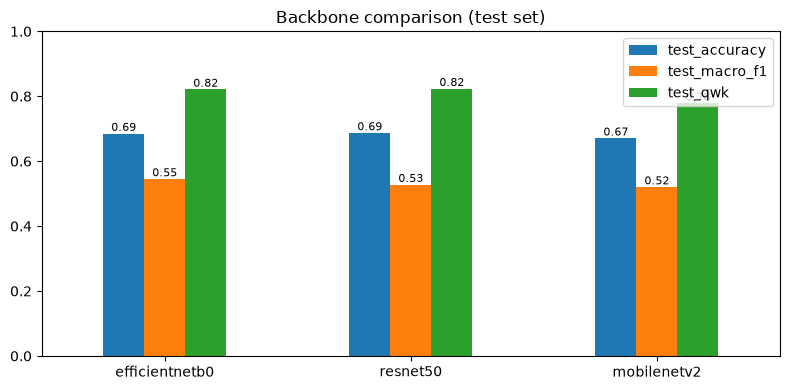

,test_accuracy,test_macro_f1,test_qwk
backbone,,,
efficientnetb0,0.685,0.545,0.821
resnet50,0.687,0.528,0.823
mobilenetv2,0.671,0.520,0.778


In [5]:
rows = log[(log["preprocess"] == "full") & (log["balance"] == "weights")].drop_duplicates("backbone", keep="last")
compare(rows, "backbone", "Backbone comparison (test set)", "compare_backbones.png")

## Preprocessing ablation (same backbone)

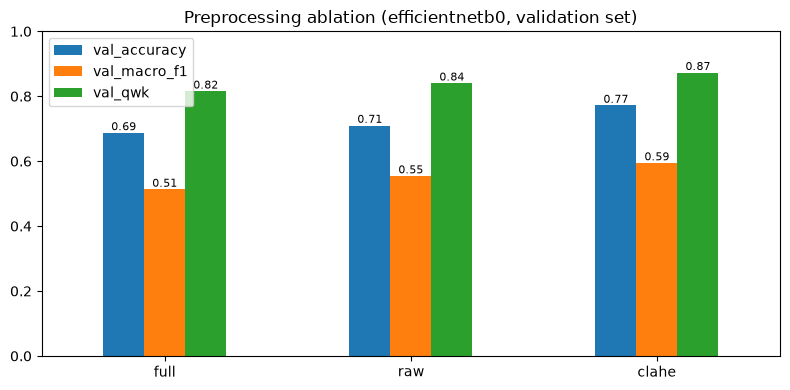

,val_accuracy,val_macro_f1,val_qwk
preprocess,,,
full,0.687,0.513,0.815
raw,0.710,0.554,0.840
clahe,0.772,0.594,0.873


In [6]:
best_backbone = log.sort_values("test_qwk", ascending=False).iloc[0]["backbone"]
rows = log[(log["backbone"] == best_backbone) & (log["balance"] == "weights")].drop_duplicates("preprocess", keep="last")
compare(rows, "preprocess", f"Preprocessing ablation ({best_backbone}, validation set)", "compare_preprocessing.png",
        metrics=("val_accuracy", "val_macro_f1", "val_qwk"))

Use **validation** scores for design decisions (ablation, tuning) and report **test** scores only for the final model; choosing settings by test score would leak information from the test set.

## Class-balancing comparison

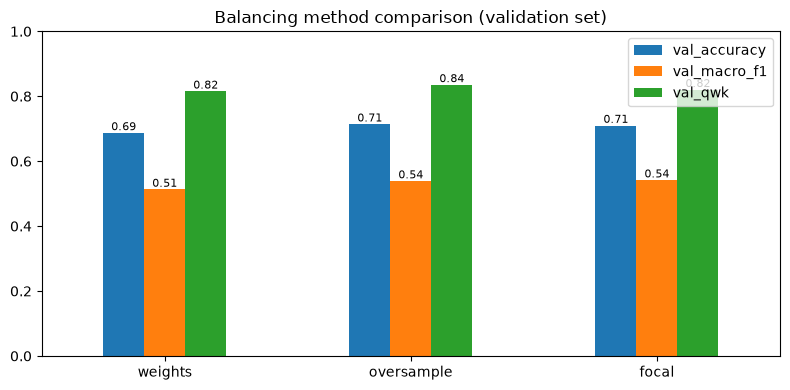

,val_accuracy,val_macro_f1,val_qwk
balance,,,
weights,0.687,0.513,0.815
oversample,0.714,0.539,0.835
focal,0.710,0.542,0.820


In [7]:
rows = log[(log["backbone"] == best_backbone) & (log["preprocess"] == "full")].drop_duplicates("balance", keep="last")
compare(rows, "balance", "Balancing method comparison (validation set)", "compare_balancing.png",
        metrics=("val_accuracy", "val_macro_f1", "val_qwk"))

## Per-class recall of the best run (shows whether rare stages improved)

In [8]:
best = log.sort_values("val_qwk", ascending=False).iloc[0]["exp_name"]
print("Best run by validation QWK:", best)
rep = pd.read_csv(config.MODELS_DIR / best / "test" / "classification_report.csv", index_col=0)
rep.round(3)

Best run by validation QWK: effb0_clahe_weights


,precision,recall,f1-score,support
No DR,0.970,0.954,0.962,241.000
Mild,0.390,0.479,0.430,48.000
Moderate,0.716,0.619,0.664,134.000
Severe,0.405,0.708,0.515,24.000
Proliferative,0.594,0.487,0.535,39.000
accuracy,0.765,0.765,0.765,0.765
macro avg,0.615,0.650,0.621,486.000
weighted avg,0.785,0.765,0.771,486.000
